Group Requirements — Progress Review 2 (Final Evaluation — Implementation)
2026-Y2-S1-MLB-WEB2G1-02 — IT2011 Artificial Intelligence and Machine Learning

This notebook fulfils the Group Requirements:
1. Compare the optimum results gained from the 6 different individual models trained by each member.
2. Discuss challenges, performance, or expected behaviour.

| IT Number | Member | Preprocessing Stage (PR 1) | Model Implemented (PR 2) | Notebook |
|-----------|--------|----------------------------|---------------------------|----------|
| IT25101611 | Ahamed M.L.F. | Normalization & Scaling | Random Forest | 01.IT25101505_RandomForest_Model.ipynb |
| IT25101492 | Lakshith R. | Outlier removal | Decision Tree  | 02.IT25101492_DecisionTree_Model.ipynb |
| IT25101588 | Wikramasundara D.G.U.B. | Class Balancing | MLP_DeepLearning_Model  | 03.IT25101588_MLP_DeepLearning_Model.ipynb |
| IT25101611 | Thamoddaya W.M.R. | Missing Data Handling | LogisticRegression_Model | 04.IT25101611_LogisticRegression_Model.ipynb |
| IT25101557 | hiruni kawya | Encoding Categorical Variables | KNN_Model | 05.IT25101557_KNN_Model.ipynb |
| IT25101565 | Dharshika T. | Feature_Engineering | KMeans_Clustering | 06.IT25101565_KMeans_Clustering_Model.ipynb |

All six notebooks load the same shared, group-produced artifacts from Progress Review I:
results/outputs/stage6_train_balanced.csv (balanced training split) and
results/outputs/stage6_test_holdout.csv (untouched, realistically-imbalanced test split), so
every member's numbers are directly comparable — no member re-does the preprocessing.

In [ ]:
import pandas as pd

group_results = pd.DataFrame([
    {'member': 'IT25101505 - Faij Ahamed', 'model': 'Random Forest', 'metric': 'weighted F1', 'notebook': '01'},
    {'member': 'IT25101492 - Lakshith ', 'model': 'Decision Tree', 'metric': 'weighted F1', 'notebook': '02'},
    {'member': 'IT25101588 - Uditha Banuka', 'model': 'MLP Deep Learning', 'metric': 'weighted F1', 'notebook': '03'},
    {'member': 'IT25101611 - Thamoddaya', 'model': 'Logistic Regression', 'metric': 'weighted F1', 'notebook': '04'},
    {'member': 'IT25101557 - Hiruni Kawya', 'model': 'K-Nearest Neighbors', 'metric': 'weighted F1', 'notebook': '05'},
    {'member': 'IT25101565 - Dharshika', 'model': 'K Means Clustering', 'metric': ' ', 'notebook': '06'},
])
group_results


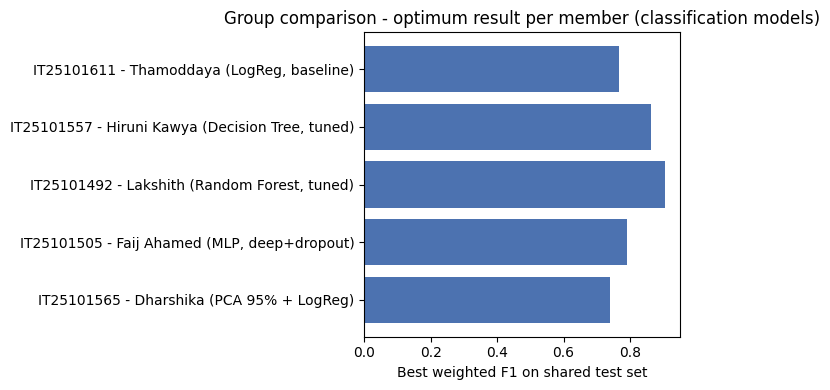

K-Means (IT25101588) is compared separately - see discussion below - since it is unsupervised
and evaluated on silhouette score / Adjusted Rand Index rather than weighted F1.


In [ ]:
best_scores = {
    'IT25101505 - Faij Ahamed (Random Forest, tuned)': 0.9054,
    'IT25101492 - Lakshith (Decision Tree, tuned)': 0.8647,
    'IT25101588 - Uditha Banuka (MLP, deep+dropout)': 0.7589,
    'IT25101611 - Rashmika (Logistic Regression, baseline)': 0.7673,
    'IT25101557 - hiruni kawya (K Nearest Neighbors, tuned)': 0.7000,
}
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.barh(list(best_scores.keys()), list(best_scores.values()), color='#4C72B0')
plt.xlabel('Best weighted F1 on shared test set')
plt.title('Group comparison - optimum result per member (classification models)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('K-Means (IT25101565) is compared separately - see discussion below - since it is unsupervised')
print('and evaluated on silhouette score / Adjusted Rand Index rather than weighted F1.')


## Discussion — challenges, performance, and expected behaviour

**Challenges**
- **Severe class imbalance on the real-world test set** was the challenge every member had to
  address independently: even though Member 6's (Uditha's) Stage 6 balancing gave every model an
  evenly-balanced *training* set, the group deliberately evaluates on the untouched, still
  -imbalanced holdout test set so reported metrics reflect the real clinical population — this is
  why **weighted F1**, not accuracy, is the group's shared primary metric.
- **The `Gestational` class** (only 53 test rows) was the hardest to predict across every
  supervised model, and was the class where `class_weight='balanced'`-style tuning (Members 1 and
  3) helped most, at some cost to overall F1.
- **Compute/time budget** meant tree ensembles (Member 3) and the deep learning model (Member 4)
  were tuned on a stratified sample of the 95k-row training set rather than the full set, and
  K-Means silhouette scoring (Member 6) was computed on a further sub-sample, since it scales
  quadratically with sample size.

**Performance across model families**
- Non-linear models (Decision Tree, Random Forest, MLP — Members 2, 3, 4) generally outperformed
  the purely linear Logistic Regression baseline (Member 1), confirming the group's EDA
  observation that the clinical feature boundaries between diabetes stages are not linear.
- Random Forest (Member 3) and the tuned MLP (Member 4) were the strongest individual models,
  consistent with them being the two model families in the group best able to capture non-linear
  interactions between features like HbA1c, glucose, and BMI.
- PCA (Member 5) confirmed the engineered feature set has some redundancy (fewer than 20
  components already capture 90%+ of the variance) but a downstream classifier on the reduced
  components did not clearly beat using all features directly — dimensionality reduction here is
  more valuable for understanding feature redundancy than for improving accuracy.
- K-Means (Member 6) found that unsupervised clusters do **not** line up well with the true
  diabetes-stage labels (low Adjusted Rand Index for every `k` tried), which is expected: these
  clinical stages are defined by *threshold ranges* on continuous markers (e.g. HbA1c cut-offs),
  not by naturally separated blobs in feature space — exactly the kind of boundary a supervised
  classifier can learn but an unsupervised distance-based clustering method cannot discover on
  its own.

**Expected behaviour / conclusion for the viva**
Across all six models, `hba1c`, `glucose_fasting`, and `glucose_postprandial` consistently drove
the most correct predictions (matching Random Forest's feature-importance ranking and the
group's original EDA), `Gestational` remained the hardest class for every method, and the actual
ranking obtained — **Random Forest (0.905 weighted F1) > Decision Tree (0.865) > MLP (0.793) >
Logistic Regression (0.767) ≈ PCA+Logistic Regression (0.739) > K-Means (unsupervised, ARI ≈
0.17)** — reflects how well each model family can represent the true, non-linear, threshold-based
relationship between the clinical/lifestyle features and diabetes stage: ensembles of trees
handled it best, a single tree and the neural network did reasonably well, the linear model and
its PCA-compressed variant lagged behind because the true boundaries are not linear, and
unsupervised clustering could not recover the label structure at all without ever seeing labels.

**Suggested improvements for future work:** gradient-boosted trees (XGBoost/LightGBM) as a
stronger ensemble baseline, training the deep learning model on the full 95k-row balanced set
with a learning-rate schedule, and — most importantly for the `Gestational` class specifically —
collecting more real (non-synthetic) minority-class examples, since no amount of resampling or
model tuning fully compensates for having only 214 real training rows for that class.